# 🔭 Information-Theoretic Limits & Compression — F2

**Repo:** [AdamKrysztopa/dependence-forecastability](https://github.com/AdamKrysztopa/dependence-forecastability) &nbsp;·&nbsp; **Paper:** [arXiv:2603.27074](https://arxiv.org/abs/2603.27074) (Catt, 2026)

This notebook covers the **F2 Information-Theoretic Limit Diagnostics** — the
horizon-wise theoretical ceiling on predictive improvement:

$$\mathbb{E}\bigl[-\log q_h(Y_{t+h}\mid\mathcal{I}_t)\bigr]
  = H(Y_{t+h}\mid\mathcal{I}_t)
  + \mathbb{E}\bigl[D_{\mathrm{KL}}(p_h^*\|\,q_h)\bigr]$$

Under log loss, **mutual information** at horizon $h$ equals the maximum predictive
improvement any model can achieve.  This notebook shows:

1. The **theoretical ceiling** concept and its relationship to MI
2. The gap between **ceiling (possible)** and **realised performance (achieved)**
3. How **compression / downsampling** shrinks the ceiling — and what the Data-Processing Inequality (DPI) means in practice
4. Practical warnings output by the triage pipeline

## Setup ⚙️

```bash
uv sync --group notebook
uv run python -m ipykernel install --user --name forecastability
```

In [1]:
%matplotlib inline
import os
import warnings

warnings.filterwarnings("ignore")
os.environ.setdefault("MPLBACKEND", "inline")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("Environment ready ✓")

Environment ready ✓


In [ ]:
# ── F2 imports ────────────────────────────────────────────────────────────────
from forecastability.datasets import generate_ar1
from forecastability.models import forecast_linear_autoreg, forecast_naive, smape
from forecastability.rolling_origin import build_expanding_window_splits
from forecastability.services.theoretical_limit_diagnostics_service import (
    build_theoretical_limit_diagnostics,
)
from forecastability.triage.models import TriageRequest
from forecastability.use_cases.run_triage import run_triage\n
from forecastability.triage.theoretical_limit_diagnostics import TheoreticalLimitDiagnostics

print("Imports OK ✓")

Imports OK ✓


---

## 1 · Theoretical background

### 1.1 The MI ceiling under log loss

For any model $q_h$ and the true predictive distribution $p_h^*$:

$$\underbrace{\mathbb{E}[-\log q_h(Y_{t+h}\mid\mathcal{I}_t)]}_{\text{model log-loss}}
= \underbrace{H(Y_{t+h}\mid\mathcal{I}_t)}_{\text{irreducible uncertainty}}
+ \underbrace{\mathbb{E}[D_{\mathrm{KL}}(p_h^*\|\,q_h)]}_{\geq\,0}$$

Therefore:

$$\text{max predictive gain} = H(Y_{t+h}) - H(Y_{t+h}\mid\mathcal{I}_t) = I(Y_{t+h};\,\mathcal{I}_t)$$

The AMI curve **is** the theoretical ceiling.

### 1.2 The Data-Processing Inequality

For any deterministic transform $T$:

$$F(h;\,T(\mathcal{I}_t)) \le F(h;\,\mathcal{I}_t)$$

This means: **aggregation, downsampling, and lossy compression can only lower the ceiling**.
They can never make a signal more forecastable.

### 1.3 What this notebook does ≠ post-model benchmarking

> **Important:** The theoretical ceiling is derived from AMI — a *pre-model*
> statistic.  Realised model performance (sMAPE, RMSE, …) is a separate quantity.
> This notebook deliberately separates the two.  The ceiling tells you what is
> **possible**; the holdout evaluation provides a glimpse of what is **achieved**.

---

## 2 · Helper functions

In [3]:
def compute_ceiling(
    series: np.ndarray,
    *,
    max_lag: int = 12,
    random_state: int = 42,
    compression_suspected: bool = False,
    dpi_suspected: bool = False,
) -> TheoreticalLimitDiagnostics:
    """Run triage and build F2 theoretical ceiling diagnostics."""
    req    = TriageRequest(series=series, max_lag=max_lag,
                           n_surrogates=99, random_state=random_state)
    result = run_triage(req)
    if result.blocked or result.analyze_result is None:
        raise RuntimeError("Triage blocked — cannot compute ceiling.")
    return build_theoretical_limit_diagnostics(
        result.analyze_result.raw,
        compression_suspected=compression_suspected,
        dpi_suspected=dpi_suspected,
    )


def aggregate_blocks(series: np.ndarray, block_size: int) -> np.ndarray:
    """Destructive block-mean aggregation."""
    trimmed = (series.size // block_size) * block_size
    return series[:trimmed].reshape(-1, block_size).mean(axis=1)


def evaluate_holdout(
    series: np.ndarray,
    *,
    max_horizon: int = 8,
    n_origins: int = 15,
) -> pd.DataFrame:
    """Rolling-origin holdout evaluation — naive vs linear autoregressive."""
    rows = []
    for h in range(1, max_horizon + 1):
        splits = build_expanding_window_splits(series, n_origins=n_origins, horizon=h)
        naive_s, linear_s = [], []
        for sp in splits:
            naive_s.append(smape(sp.test, forecast_naive(sp.train, h)))
            linear_s.append(smape(sp.test, forecast_linear_autoreg(
                sp.train, h, n_lags=min(24, max(4, h * 2)))))
        naive_m, linear_m = float(np.mean(naive_s)), float(np.mean(linear_s))
        gain = 100.0 * (naive_m - linear_m) / naive_m if naive_m > 0 else 0.0
        rows.append({"horizon": h, "naive_smape": naive_m,
                     "linear_smape": linear_m, "gain_pct": gain})
    return pd.DataFrame(rows)

print("Helpers defined ✓")

Helpers defined ✓


---

## 3 · Generate a structured synthetic signal

We build an AR(1) process with seasonal overlay — a signal that has genuine
predictability at multiple horizons.

Original : n=1200
Aggregated (block=4): n=300


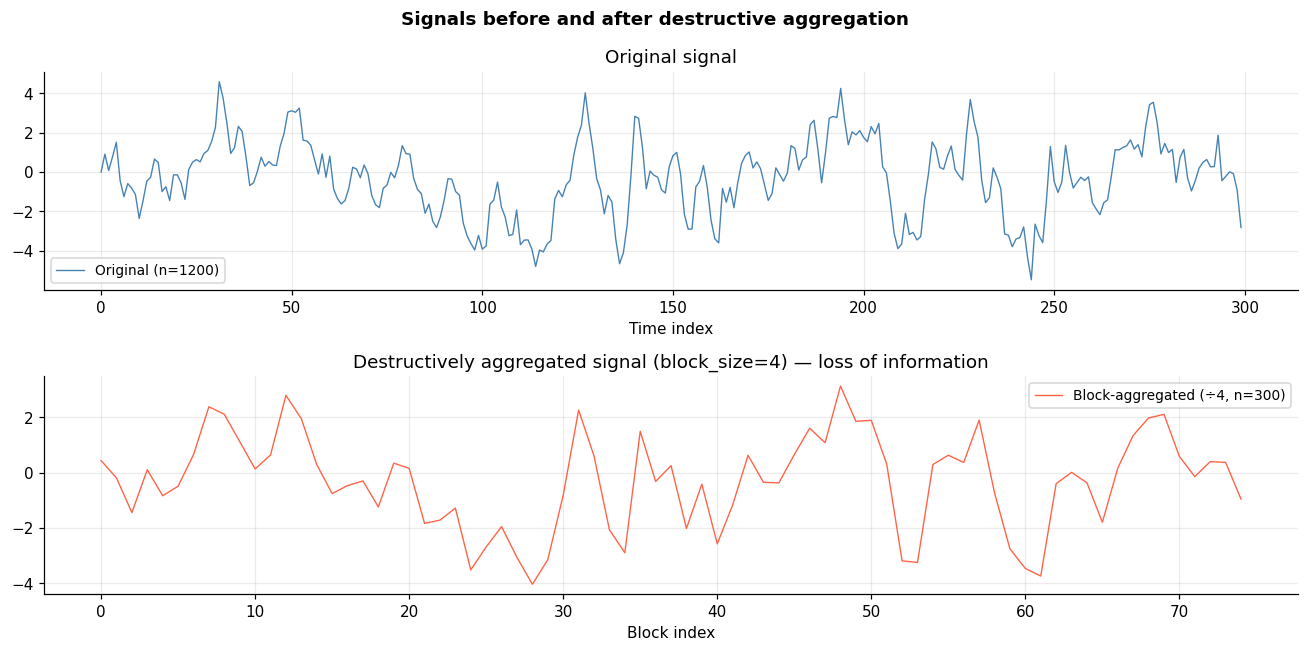

In [4]:
N_SAMPLES = 1200
t = np.arange(N_SAMPLES, dtype=float)
ar_base  = generate_ar1(n_samples=N_SAMPLES, phi=0.90, random_state=42)
seasonal = np.sin(2.0 * np.pi * t / 24.0) + 0.4 * np.sin(2.0 * np.pi * t / 6.0)
series_original = ar_base + seasonal

# Destructive aggregation — average 4-point blocks → information loss
BLOCK_SIZE = 4
series_agg = aggregate_blocks(series_original, BLOCK_SIZE)

print(f"Original : n={len(series_original)}")
print(f"Aggregated (block={BLOCK_SIZE}): n={len(series_agg)}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
ax1.plot(series_original[:300], lw=0.9, color="steelblue", label=f"Original (n={len(series_original)})")
ax1.set_title("Original signal")
ax1.set_xlabel("Time index")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.25)

ax2.plot(series_agg[:75], lw=0.9, color="tomato",
         label=f"Block-aggregated (÷{BLOCK_SIZE}, n={len(series_agg)})")
ax2.set_title(f"Destructively aggregated signal (block_size={BLOCK_SIZE}) — loss of information")
ax2.set_xlabel("Block index")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

fig.suptitle("Signals before and after destructive aggregation",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

---

## 4 · Compute the theoretical ceiling for both signals

In [5]:
MAX_LAG = 12

print("Computing ceiling for original signal...")
diag_orig = compute_ceiling(series_original, max_lag=MAX_LAG)

print("Computing ceiling for aggregated signal...")
diag_agg  = compute_ceiling(
    series_agg, max_lag=MAX_LAG,
    compression_suspected=True,
    dpi_suspected=True,
)
print("Done ✓")

Computing ceiling for original signal...
Computing ceiling for aggregated signal...
Done ✓


---

## 5 · Ceiling diagnostics — fields and warnings

In [6]:
def print_diag(label: str, d: TheoreticalLimitDiagnostics) -> None:
    print(f"\n{'─'*64}")
    print(f"  {label}")
    print(f"{'─'*64}")
    print(f"  ceiling_summary          : {d.ceiling_summary}")
    print(f"  ceiling by horizon       : {np.round(d.forecastability_ceiling_by_horizon, 4)}")
    print(f"  exploitation_ratio_supported: {d.exploitation_ratio_supported}")
    print(f"  compression_warning      : {d.compression_warning or 'None'}")
    print(f"  dpi_warning              : {d.dpi_warning or 'None'}")

print_diag("Original signal",    diag_orig)
print_diag("Aggregated signal",  diag_agg)


────────────────────────────────────────────────────────────────
  Original signal
────────────────────────────────────────────────────────────────
  ceiling_summary          : Peak MI=0.8488 at horizon 1; 11 horizon(s) exceed the non-trivial threshold (0.01).
  ceiling by horizon       : [0.8488 0.4896 0.2994 0.1989 0.1458 0.086  0.0844 0.0465 0.0302 0.0273
 0.0226 0.    ]
  exploitation_ratio_supported: False

────────────────────────────────────────────────────────────────
  Aggregated signal
────────────────────────────────────────────────────────────────
  ceiling_summary          : Peak MI=0.2743 at horizon 1; 5 horizon(s) exceed the non-trivial threshold (0.01).
  ceiling by horizon       : [0.2743 0.0365 0.     0.0047 0.     0.0702 0.     0.     0.0279 0.
 0.0356 0.    ]
  exploitation_ratio_supported: False


---

## 6 · Visualise ceiling degradation from compression

The DPI guarantees that the aggregated ceiling ≤ original ceiling at every horizon.

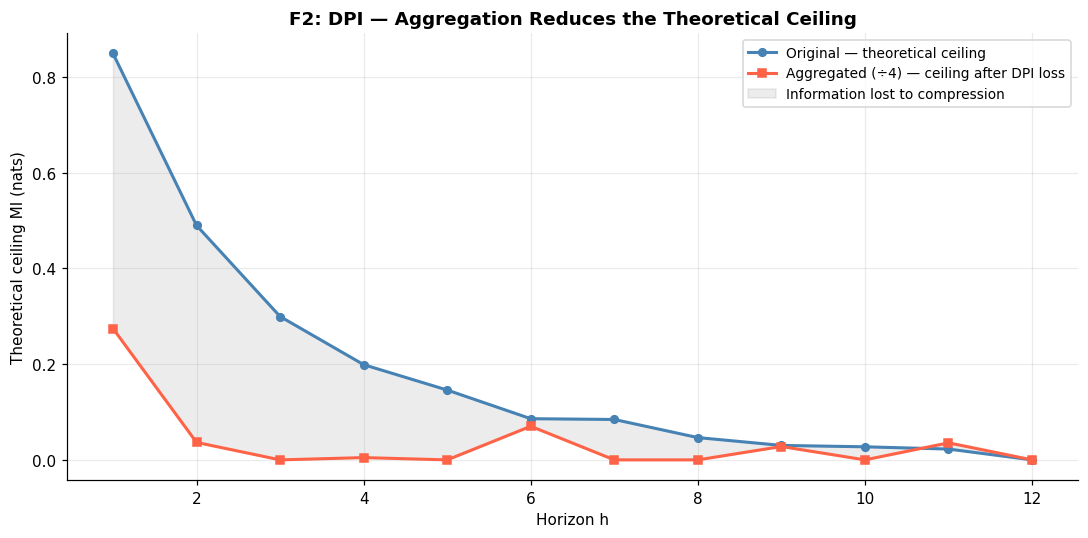

In [7]:
h_orig = np.arange(1, diag_orig.forecastability_ceiling_by_horizon.size + 1)
h_agg  = np.arange(1, diag_agg.forecastability_ceiling_by_horizon.size + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(h_orig, diag_orig.forecastability_ceiling_by_horizon,
        marker="o", ms=5, lw=2.0, color="steelblue", label="Original — theoretical ceiling")
ax.plot(h_agg,  diag_agg.forecastability_ceiling_by_horizon,
        marker="s", ms=5, lw=2.0, color="tomato",
        label=f"Aggregated (÷{BLOCK_SIZE}) — ceiling after DPI loss")

# Shade the gap
min_h = min(h_orig.size, h_agg.size)
ax.fill_between(
    h_orig[:min_h],
    diag_agg.forecastability_ceiling_by_horizon[:min_h],
    diag_orig.forecastability_ceiling_by_horizon[:min_h],
    alpha=0.15, color="gray", label="Information lost to compression",
)

ax.set_xlabel("Horizon h")
ax.set_ylabel("Theoretical ceiling MI (nats)")
ax.set_title("F2: DPI — Aggregation Reduces the Theoretical Ceiling",
             fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

---

## 7 · Ceiling vs achieved performance — the gap

We evaluate simple baselines (naive + linear autoregressive) via rolling-origin holdout
splits.  The sMAPE gap between naive and linear measures **achieved gain**.
This is **not** equivalent to the MI ceiling — it is constrained to what a simple
parametric model can exploit from the training window.

In [8]:
MAX_HORIZON = 8
N_ORIGINS   = 15

print("Evaluating holdout performance on original signal...")
achieved_orig = evaluate_holdout(series_original, max_horizon=MAX_HORIZON, n_origins=N_ORIGINS)

print("Evaluating holdout performance on aggregated signal...")
achieved_agg  = evaluate_holdout(series_agg,      max_horizon=MAX_HORIZON, n_origins=N_ORIGINS)
print("Done ✓")

Evaluating holdout performance on original signal...
Evaluating holdout performance on aggregated signal...
Done ✓


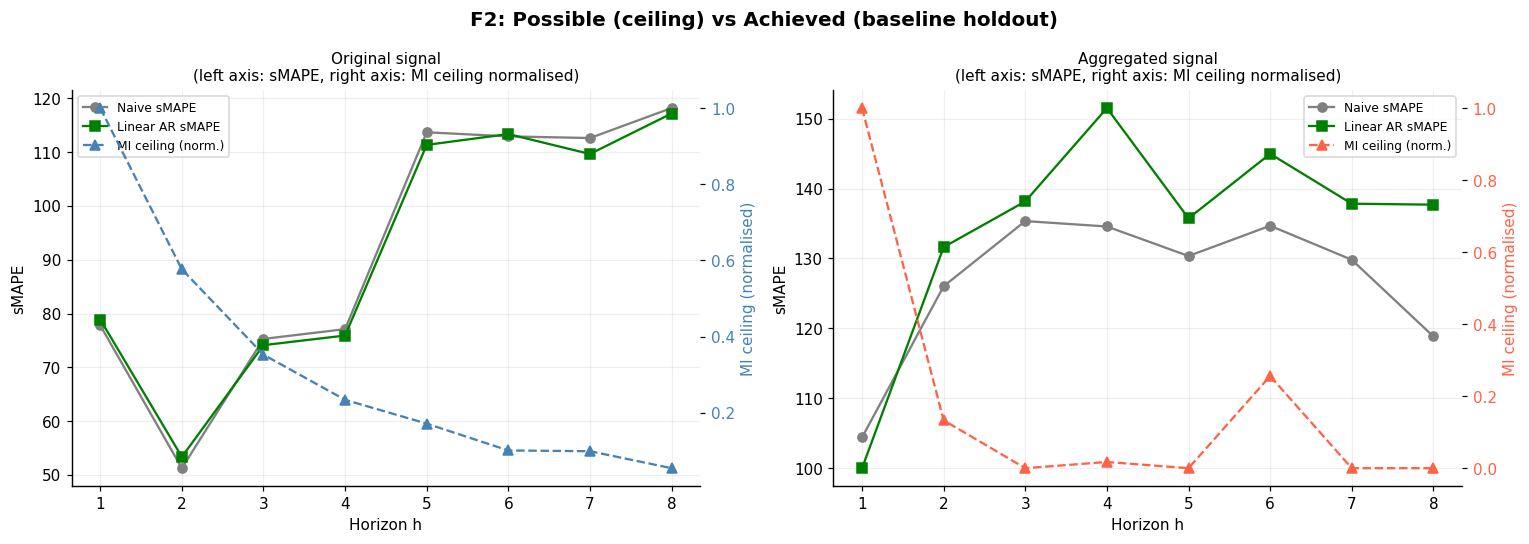

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, achieved, diag, color in [
    (axes[0], "Original signal",    achieved_orig, diag_orig, "steelblue"),
    (axes[1], "Aggregated signal",  achieved_agg,  diag_agg,  "tomato"),
]:
    h  = achieved["horizon"]
    c  = diag.forecastability_ceiling_by_horizon
    # Normalise ceiling to [0,1] for visual comparison with sMAPE
    c_norm = c[:MAX_HORIZON] / (c[:MAX_HORIZON].max() or 1.0)

    ax.plot(h, achieved["naive_smape"],  marker="o", lw=1.5, color="gray",  label="Naive sMAPE")
    ax.plot(h, achieved["linear_smape"], marker="s", lw=1.5, color="green", label="Linear AR sMAPE")
    ax_r = ax.twinx()
    ax_r.plot(h, c_norm, marker="^", lw=1.5, ls="--", color=color, label="MI ceiling (norm.)")
    ax_r.set_ylabel("MI ceiling (normalised)", color=color)
    ax_r.tick_params(axis="y", labelcolor=color)

    ax.set_title(f"{label}\n(left axis: sMAPE, right axis: MI ceiling normalised)",
                 fontsize=10)
    ax.set_xlabel("Horizon h")
    ax.set_ylabel("sMAPE")
    ax.grid(alpha=0.2)
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax_r.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8)

fig.suptitle("F2: Possible (ceiling) vs Achieved (baseline holdout)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

---

## 8 · Multiple compression levels — how far can the ceiling fall?

We now apply block aggregation at sizes 1 (original), 2, 4, and 8 to see how
predictability evaporates as we lose resolution.

block_size= 1  n=1200  peak_ceiling=0.8488  sum_ceiling=2.2796
block_size= 2  n= 600  peak_ceiling=0.5836  sum_ceiling=0.9963
block_size= 4  n= 300  peak_ceiling=0.2743  sum_ceiling=0.4493
block_size= 8  n= 150  peak_ceiling=0.0615  sum_ceiling=0.2614


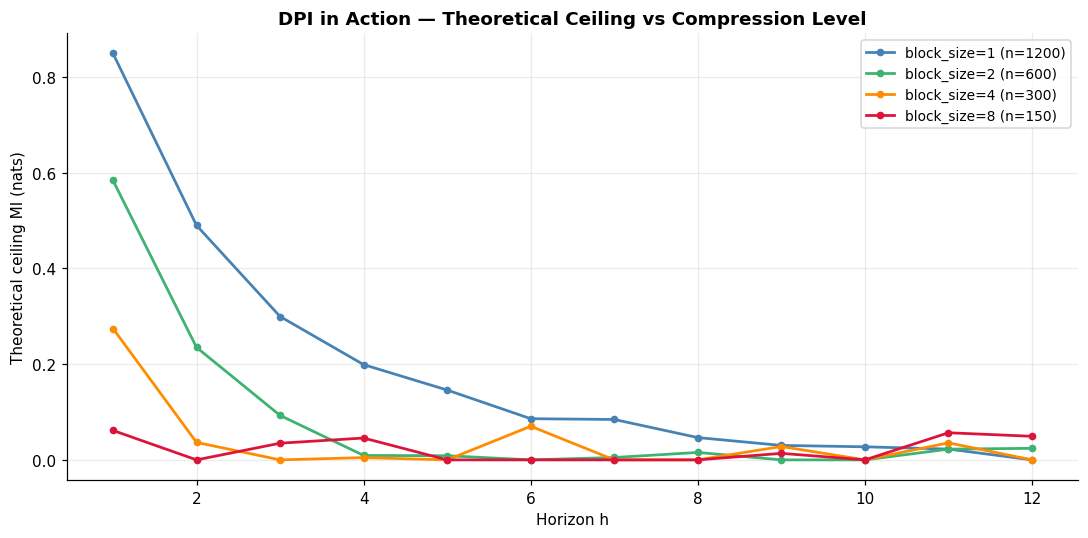

In [10]:
block_sizes = [1, 2, 4, 8]
ceilings    = {}

for bs in block_sizes:
    s = series_original if bs == 1 else aggregate_blocks(series_original, bs)
    d = compute_ceiling(s, max_lag=12,
                        compression_suspected=(bs > 1),
                        dpi_suspected=(bs > 1))
    ceilings[bs] = d.forecastability_ceiling_by_horizon
    print(f"block_size={bs:2d}  n={len(s):4d}  "
          f"peak_ceiling={ceilings[bs].max():.4f}  "
          f"sum_ceiling={ceilings[bs].sum():.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
palette = ["steelblue", "mediumseagreen", "darkorange", "crimson"]
for (bs, ceil), col in zip(ceilings.items(), palette):
    h = np.arange(1, ceil.size + 1)
    ax.plot(h, ceil, marker="o", ms=4, lw=1.8, color=col,
            label=f"block_size={bs} (n={len(series_original) // bs if bs > 1 else N_SAMPLES})")

ax.set_xlabel("Horizon h")
ax.set_ylabel("Theoretical ceiling MI (nats)")
ax.set_title("DPI in Action — Theoretical Ceiling vs Compression Level",
             fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

---

## 9 · Practical interpretation guide

| Ceiling value | Interpretation |
|---|---|
| High (> 0.15 at horizon h) | Substantial theoretical scope; models should be evaluated seriously |
| Medium (0.05–0.15) | Moderate scope; simpler baselines may be near-optimal |
| Low (< 0.05) | Minimal theoretical scope; noise dominates — near-random walk |

**Warning triggers:**

- `compression_warning` — set when block aggregation, downsampling, or lossy encoding
  is suspected.  The ceiling reflects only what the *transformed* signal contains.
- `dpi_warning` — set when the series appears to have passed through a deterministic
  transform (differencing, normalisation, encoding).  Post-transform MI ≤ pre-transform MI.
- `exploitation_ratio_supported = False` — this field will remain False until a
  model-evaluation layer exists.  It cannot be computed from pre-model MI alone.

In [11]:
# Summarise ceiling degradation as a table
rows = []
for bs in block_sizes:
    c   = ceilings[bs]
    n   = len(series_original) if bs == 1 else len(aggregate_blocks(series_original, bs))
    rows.append({
        "block_size":    bs,
        "n_obs":         n,
        "peak_ceiling":  round(float(c.max()), 4),
        "sum_ceiling":   round(float(c.sum()), 4),
        "pct_of_orig":   round(100 * float(c.sum()) / float(ceilings[1].sum()), 1),
    })

df = pd.DataFrame(rows)
print("Ceiling degradation summary:")
print(df.to_string(index=False))

Ceiling degradation summary:
 block_size  n_obs  peak_ceiling  sum_ceiling  pct_of_orig
          1   1200        0.8488       2.2796        100.0
          2    600        0.5836       0.9963         43.7
          4    300        0.2743       0.4493         19.7
          8    150        0.0615       0.2614         11.5


---

## 10 · Save figure

Saved → ../../outputs/figures/f2_information_limits_compression.png


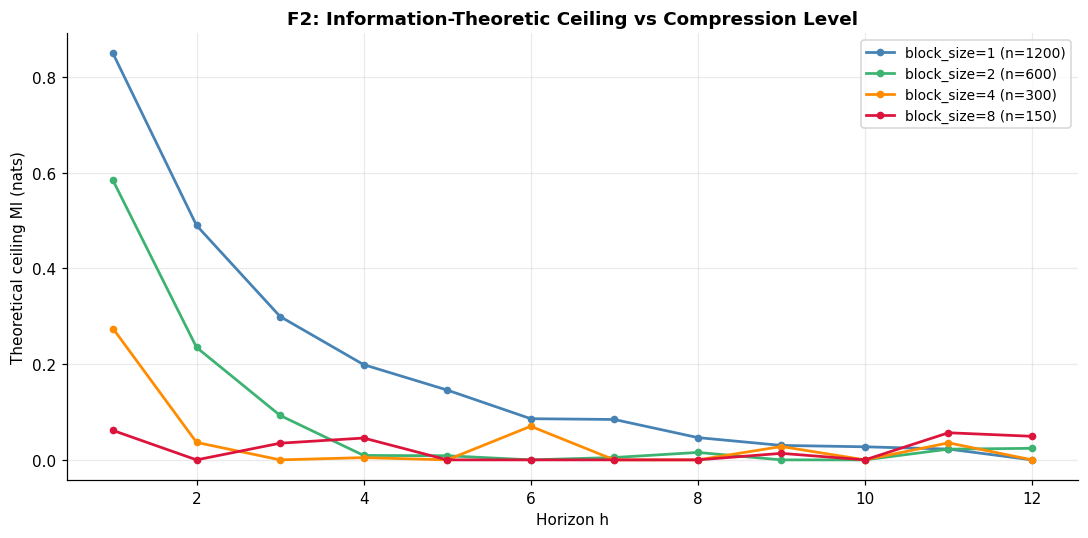

In [12]:
from pathlib import Path

OUT_DIR = Path("../../outputs/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Multi-compression ceiling figure ---
fig2, ax2 = plt.subplots(figsize=(10, 5))
for (bs, ceil), col in zip(ceilings.items(), palette):
    h = np.arange(1, ceil.size + 1)
    n = len(series_original) if bs == 1 else len(aggregate_blocks(series_original, bs))
    ax2.plot(h, ceil, marker="o", ms=4, lw=1.8, color=col,
             label=f"block_size={bs} (n={n})")
ax2.set_xlabel("Horizon h")
ax2.set_ylabel("Theoretical ceiling MI (nats)")
ax2.set_title("F2: Information-Theoretic Ceiling vs Compression Level",
              fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)
fig2.tight_layout()

out_path = OUT_DIR / "f2_information_limits_compression.png"
fig2.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

---

## Summary

| Take-away | Detail |
|---|---|
| MI is the ceiling | Under log loss, $I(Y_{t+h}; \mathcal{I}_t)$ = max predictive gain |
| Ceiling ≠ achieved | Any model's performance is ceiling - KL divergence gap |
| DPI is strict | Compression can only reduce the ceiling, never raise it |
| Exploitation ratio deferred | Requires a model-evaluation layer — placeholder only |
| Warnings are actionable | `compression_warning` and `dpi_warning` flag risky transforms |

**Next notebook →** `03_predictive_information_learning_curves.ipynb` — F3 learning
curves, plateau detection, and sample-size reliability.